# Example A: Annotated Heatmap with Colorbar

This example features code to generate the following figure:

![example_a](../img/example_a.png)

A recorded walkthrough of this notebook can be found [here](https://northeastern.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=5eaae24c-d66b-44b6-a3aa-b47101401757). You are invited to provide your feedback to today's workshop session with this [survey](https://forms.office.com/r/7EtNFtUDm0?origin=lprLink) to be completed at any time.


First we include a cell to import the packages we'll be using:

In [40]:
import matplotlib.pyplot as plt

import numpy as np

Here we define the data we'd like to plot:

In [41]:
vegetables = ['Cucumber', 'Tomato', 'Lettuce', 'Asparagus', 
              'Potato', 'Wheat', 'Barley']
row_indices = range(len(vegetables)) # a series of integers spanning the length of the list "vegetables"

farmers = ['Farmer Joe', 'Upland Bros.', 'Smith Gardening', 
           'Agrifun', 'Organiculture', 'BioGoods Ltd.', 'Cornylee Corp.']
col_indices = range(len(farmers))

harvest = np.array([[0.8, 2.4, 2.5, 3.9, 0.0, 4.0, 0.0], # a 2-dimensional numpy array storing our raw data as a matrix
                    [2.4, 0.0, 4.0, 1.0, 2.7, 0.0, 0.0],
                    [1.1, 2.4, 0.8, 4.3, 1.9, 4.4, 0.0],
                    [0.6, 0.0, 0.3, 0.0, 3.1, 0.0, 0.0],
                    [0.7, 1.7, 0.6, 2.6, 2.2, 6.2, 0.0],
                    [1.3, 1.2, 0.0, 0.0, 0.0, 3.2, 5.1],
                    [0.1, 2.0, 0.0, 1.4, 0.0, 1.9, 6.3]])

Calling `plt.subplots()` allows us to separate the figure space and plotted axes into two separate objects (`fig` and `ax`, respectively). This is useful for when multiple plots (`ax` objects) need to be displayed on a single figure (`fig` object). In this example, we only show one plot on the figure as a grid of colored pixels using `ax.imshow()`.

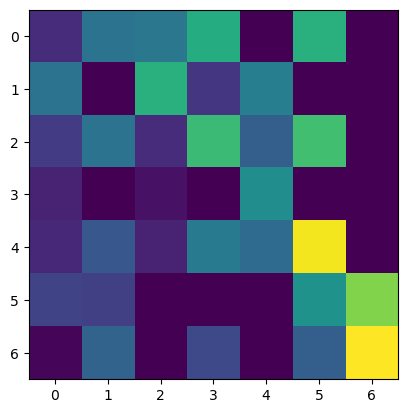

In [42]:
fig, ax = plt.subplots()
im = ax.imshow(harvest)

Using the methods `ax.set_xticks` and `ax.set_yticks`, we can label the row and column indices with the names of each respective farmer and vegetable they represent. 

Text(0.5, 1.0, 'Harvest of Local Farmers (in tons/year)')

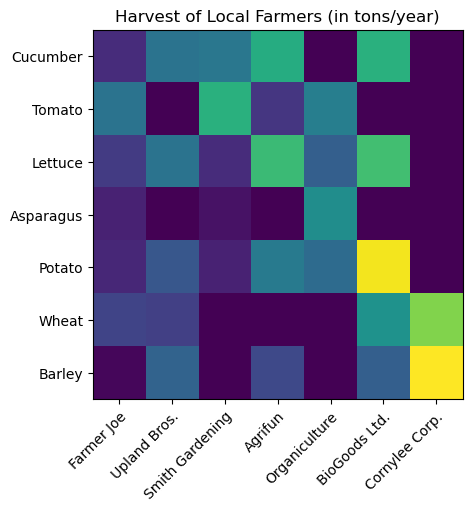

In [43]:
fig, ax = plt.subplots()
im = ax.imshow(harvest)

ax.set_xticks(col_indices,
              labels=farmers,
              rotation=45, # add a slight rotation to make vertical labels more legible
              ha='right',
              rotation_mode='anchor')

ax.set_yticks(row_indices,
              labels=vegetables)

# We can add a title using a similar method:
ax.set_title('Harvest of Local Farmers (in tons/year)')

Sometimes it can be useful to annotate each pixel of a heatmap with its exact numerical value. Here, we use Python `for` loops to iterate through the indices we defined in our data cell and call the `ax.text()` method to display the value of each element of the matrix.

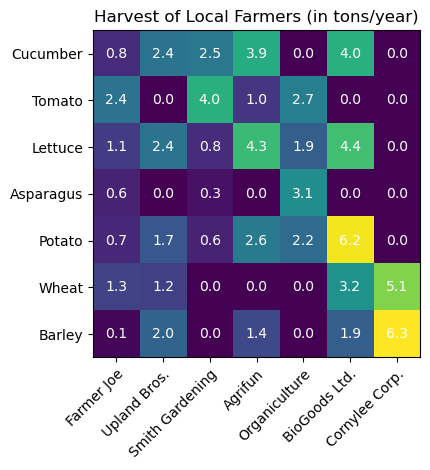

In [44]:
fig, ax = plt.subplots()
im = ax.imshow(harvest)

ax.set_xticks(col_indices,
              labels=farmers,
              rotation=45,
              ha='right',
              rotation_mode='anchor')

ax.set_yticks(row_indices,
              labels=vegetables)

ax.set_title('Harvest of Local Farmers (in tons/year)')

# Iterate through each row index:
for i in row_indices:
    # Iterate through each column index:
    for j in col_indices:
        # Show the value of each row/col element on its pixel:
        text = ax.text(j, i, harvest[i, j],
                       ha='center', va='center', color='w')
        
fig.tight_layout()

### Using helper functions to repurpose code faster

It can often be useful to "wrap" plotting code into a custom function when you need to make the same type of plot for different sets of data. Here we use `def` to define a new function called `plot_heatmap()`. The first three "arguments" of the function (`data`, `row_labels`, and `col_labels`) are required inputs, but we can give our function some flexibility by adding extra optional arguments which each have values by default unless you want to change them.

The included optional arguments can be used as follows:
- `title`: Add a title to your heatmap as a Python string like 'Heatmap Title'. No title is displayed by default.
- `cmap`: Specify the matplotlib colormap to use for the resulting plot. The default is called 'viridis', but simple names of other colormaps can be found [here](https://matplotlib.org/stable/users/explain/colors/colormaps.html)
- `cbar_label`: Add and label a colorbar showing how the range of colors correspond to the input data. No color bar is displayed by default.
- `annotation_text_color`: Specify the color of the text showing each pixel's value. Text is displayed in white by default.

In [45]:
def plot_heatmap(data, row_labels, col_labels, 
                 title=None, cmap='viridis', cbar_label=None,
                 annotation_text_color='white'):

    row_indices = range(len(row_labels))
    col_indices = range(len(col_labels))
    
    fig, ax = plt.subplots()
    im = ax.imshow(data, cmap=cmap)

    # Add a colorbar and label it if cbar_label was specified:
    if cbar_label:
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel(cbar_label, rotation=-90, va='bottom')

    ax.set_xticks(col_indices,
                labels=col_labels,
                rotation=45,
                ha='right',
                rotation_mode='anchor')

    ax.set_yticks(row_indices,
                labels=row_labels)

    # Only add a title if it was given:
    if title:
        ax.set_title(title)

    for i in row_indices:
        for j in col_indices:
            text = ax.text(j, i, data[i, j],
                        ha='center', va='center',
                        color=annotation_text_color)
            
    fig.tight_layout()

Once the above cell is run, we can call our newly created function with our desired arguments to output the same plot with less written code:

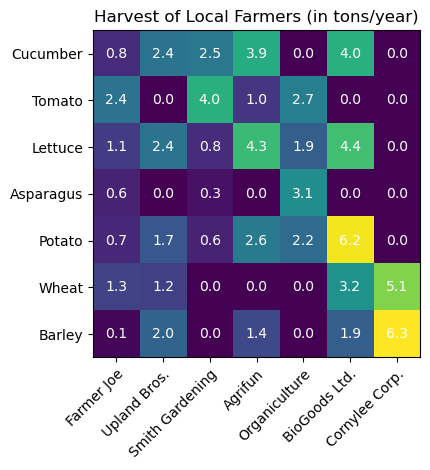

In [46]:
plot_heatmap(harvest, vegetables, farmers,
             title='Harvest of Local Farmers (in tons/year)')

We can additionally modify the optional arguments to easily change how the resulting heatmap looks. Try out some different combinations!

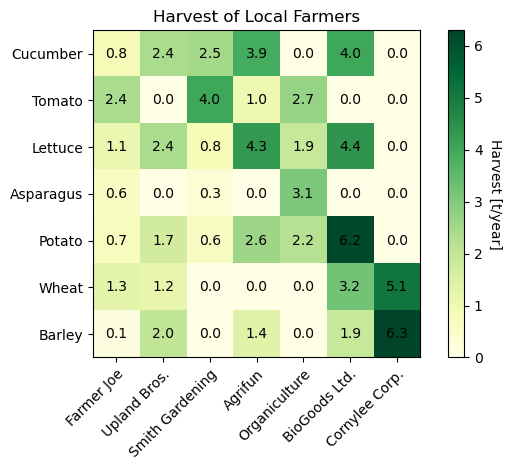

In [47]:
plot_heatmap(harvest, vegetables, farmers,
             title='Harvest of Local Farmers',
             cmap='YlGn',
             cbar_label='Harvest [t/year]',
             annotation_text_color='black')

Example from [Matplotlib gallery](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html)